# Clasificación de Perros y Gatos con MLP

Este notebook desarrolla un modelo de clasificación binaria de imágenes (perro vs. gato) 
utilizando un Perceptrón Multicapa (MLP), a partir de una variante del dataset Oxford-IIIT Pet.

## 1. Introducción y exploración del dataset

En esta primera sección cargamos las imágenes, identificamos las clases (perro/gato) a 
partir del nombre de archivo, y exploramos las características generales del conjunto de datos.

In [1]:
import os

data_dir = "../data/images/images"
archivos = [f for f in os.listdir(data_dir) if f.endswith(".jpg")]

print(f"Total de imágenes .jpg encontradas: {len(archivos)}")
print("Ejemplos de nombres de archivo:", archivos[:5])

Total de imágenes .jpg encontradas: 7390
Ejemplos de nombres de archivo: ['British_Shorthair_122.jpg', 'beagle_160.jpg', 'Ragdoll_142.jpg', 'english_setter_188.jpg', 'Maine_Coon_238.jpg']


## 2. Definición de la variante binaria (perro vs. gato)

El dataset original tiene 37 clases (razas). Para este proyecto, se define una variante 
binaria: cada imagen se etiqueta como "perro" o "gato" según si el nombre del archivo 
comienza con mayúscula (convención del dataset para razas de gato) o minúscula (razas de perro).

In [2]:
etiquetas = []

for archivo in archivos:
    primera_letra = archivo[0]
    if primera_letra.isupper():
        etiquetas.append("gato")
    else:
        etiquetas.append("perro")

from collections import Counter
conteo = Counter(etiquetas)
print("Conteo de imágenes por clase:")
print(conteo)

Conteo de imágenes por clase:
Counter({'perro': 4990, 'gato': 2400})


## 3. Hallazgo: desbalance de clases

Se observa un desbalance entre clases: 4.990 imágenes de perro (67.5%) y 2.400 imágenes 
de gato (32.5%). Este desbalance deberá considerarse durante el entrenamiento, ya que 
el modelo podría sesgarse hacia la clase mayoritaria (perro) si no se toman medidas 
correct

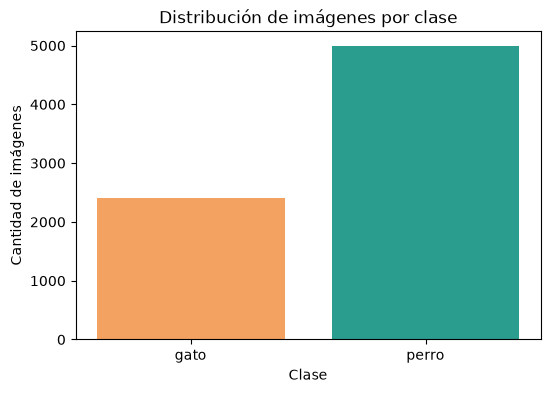

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(conteo.keys(), conteo.values(), color=["#f4a261", "#2a9d8f"])
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.savefig("../images/distribucion_clases.png")
plt.show()